# Growth-rate review

Everything the `growth_review` package holds, and how the figures are built from it.

The package separates three things that get mixed together in growth plots and
should not be: published **measurements**, projected **forecast** precisions, and
tabulated **theory** curves. They never share a marker style here, because a
forecast bar sits exactly on the model curve by construction — a reader who takes
one for data concludes the model is confirmed at that precision.

## 1. What is in the package

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import growth_review as gr

gr.use_style()
print(gr.summary_table())

name                             kind         probe        method  summary
--------------------------------------------------------------------------------------------------------------
bao_compilation                  measurement  bao          -       BAO distance measurements 2009-2020, 6dFGS through eBOSS DR16 + Lya.
bao_sdss_final                   measurement  bao          -       SDSS-family consensus BAO distance ratios.
fsigma8_pv                       measurement  fsigma8      pv      35 published fsigma8 values from peculiar-velocity data, one row per measurement, with asymmetric errors, method family and full provenance.
fsigma8_rsd                      measurement  fsigma8      rsd     Galaxy-clustering (RSD) fsigma8, 2dF through DESI DR1 full shape.
fsigma8_sdss_final               measurement  fsigma8      rsd     fsigma8 as quoted in the SDSS final cosmology paper, with z ranges.
s8_weak_lensing                  measurement  s8           -       S8 from cosmic shear: DES

Each entry carries its own caveats. These are not decoration — they are the
things that make a number wrong if ignored.

In [2]:
for name in ["fsigma8_pv", "fsigma8_rsd", "fsigma8_sn_pv", "cola_growth_fr"]:
    d = gr.get(name)
    print(f"\n{d.name}  [{d.kind} / {d.probe}]  {d.source}")
    for c in d.caveats:
        print("   ! " + c)


fsigma8_pv  [measurement / fsigma8]  compiled 2026-08-13/14; every row traced to its own paper
   ! Rows are NOT independent: 6dFGSv, SDSS PV, SFI++, 2MTF and 2M++ recur across most of them, and CF3/CF4 contain several. Never average.
   ! The four DESI_DR1_* rows are three correlated estimators on one dataset plus their consensus; load_fsigma8() keeps only the consensus by default.
   ! Six rows normalise to the LINEAR sigma8 (sigma8_norm='lin'); Carrick et al. quote both for the same data and they differ by 6.5%.
   ! method_family='vd_dynamical' is declared and EMPTY: every published velocity-density comparison predicts the velocity field with linear dynamics. The particle-evolving analyses (Valade+2026, Manticore, Boruah-Lavaux-Hudson 2022, Graziani+2019) publish reconstructions, not a growth rate. See methods.EMPTY_FAMILY_EVIDENCE.
   ! 'Forward model' in Boubel2024, Stiskalek2026, Boruah2020 and Stahl2021 means the DISTANCE INDICATOR, not the field dynamics -- Stiskalek's abstra

## 2. One tidy frame for every fsigma8 constraint

In [3]:
df = gr.load_fsigma8()
print(df.groupby(["kind", "method"]).size().to_string())
df.head(8)

kind         method
forecast     pv        36
             rsd       32
measurement  pv        28
             rsd       25


,key,ref,label,z,value,err_lo,err_hi,frac_err,kind,probe,method,dataset,method_family,fit_technique,sigma8_norm,provenance
0,Johnson2014,Johnson et al.,6dFGSv,0.000,0.418,0.065,0.065,NaN,measurement,fsigma8,pv,fsigma8_pv,field_level,likelihood,unstated,src
1,Howlett2017,Howlett et al.,2MTF,0.000,0.510,0.080,0.090,NaN,measurement,fsigma8,pv,fsigma8_pv,two_point,likelihood,unstated,src
2,AdamsBlake2017,Adams & Blake,6dFGS,0.000,0.424,0.064,0.067,NaN,measurement,fsigma8,pv,fsigma8_pv,field_level,likelihood,unstated,src
3,LilowNusser2021,Lilow & Nusser,CF3+2MRS,0.013,0.367,0.060,0.060,NaN,measurement,fsigma8,pv,fsigma8_pv,vd_linear,likelihood,lin,src
4,Boubel2024,Boubel et al.,Tully-Fisher forward model,0.017,0.350,0.030,0.030,NaN,measurement,fsigma8,pv,fsigma8_pv,vd_linear,forward_model,unstated,src
5,Davis2011,Davis et al.,SFI++,0.020,0.310,0.040,0.040,NaN,measurement,fsigma8,pv,fsigma8_pv,vd_linear,chi2,unstated,der
6,Carrick2015,Carrick et al.,2M++,0.020,0.401,0.024,0.024,NaN,measurement,fsigma8,pv,fsigma8_pv,vd_linear,chi2,lin,der
7,Huterer2017,Huterer et al.,low-z SNe + galaxy velocities,0.020,0.428,0.045,0.048,NaN,measurement,fsigma8,pv,fsigma8_pv,field_level,likelihood,unstated,src


Four peculiar-velocity rows have no effective redshift. That is not a gap in the
compilation: the authors assign none (Stiskalek's Table 1 prints "—" for the
joint TFR+SNe fit, Stahl quotes none, Wang frames the analysis in survey depth).
They have no position on an fsigma8(z) axis, so they are dropped rather than
placed at a redshift nobody published.

In [4]:
gr.io.dropped_without_z()[["key", "ref", "value", "err_lo", "err_hi"]]

,key,ref,value,err_lo,err_hi
0,Stahl2021,Stahl et al.,0.390,0.022,0.022
1,Stiskalek2026,Stiskalek,0.412,0.018,0.018
2,Wang2026_group,Wang et al.,0.384,0.194,0.116
3,Wang2026_local,Wang et al.,0.569,0.060,0.054


## 3. The fiducial cosmology

In [5]:
cosmo = gr.FlatLCDM()
z = np.array([0.0, 0.07, 0.5, 1.0, 1.5])
for zi in z:
    print(f"z={zi:4.2f}   f={cosmo.growth_rate(zi):.4f}   "
          f"Om(z)^0.55={cosmo.omega_m_z(zi)**0.55:.4f}   "
          f"fsigma8={cosmo.fsigma8(zi):.4f}")

z=0.00   f=0.5260   Om(z)^0.55=0.5286   fsigma8=0.4266
z=0.07   f=0.5674   Om(z)^0.55=0.5693   fsigma8=0.4435
z=0.50   f=0.7601   Om(z)^0.55=0.7598   fsigma8=0.4742
z=1.00   f=0.8761   Om(z)^0.55=0.8755   fsigma8=0.4315
z=1.50   f=0.9309   Om(z)^0.55=0.9305   fsigma8=0.3745


f is integrated, not approximated by Omega_m(z)^0.55 — the approximation is good
to about 0.5% at z = 0, and assuming the GR growth index is exactly what a
growth review must not do silently. `fsigma8_gamma` gives the approximation when
you want it as a comparison curve.

## 4. Linear, log, or both

The compilation spans z = 0 to z = 1.5. Peculiar velocities live below z = 0.1
and clustering above it, so no single scale serves both. Four are available;
this is what each does to the same data.

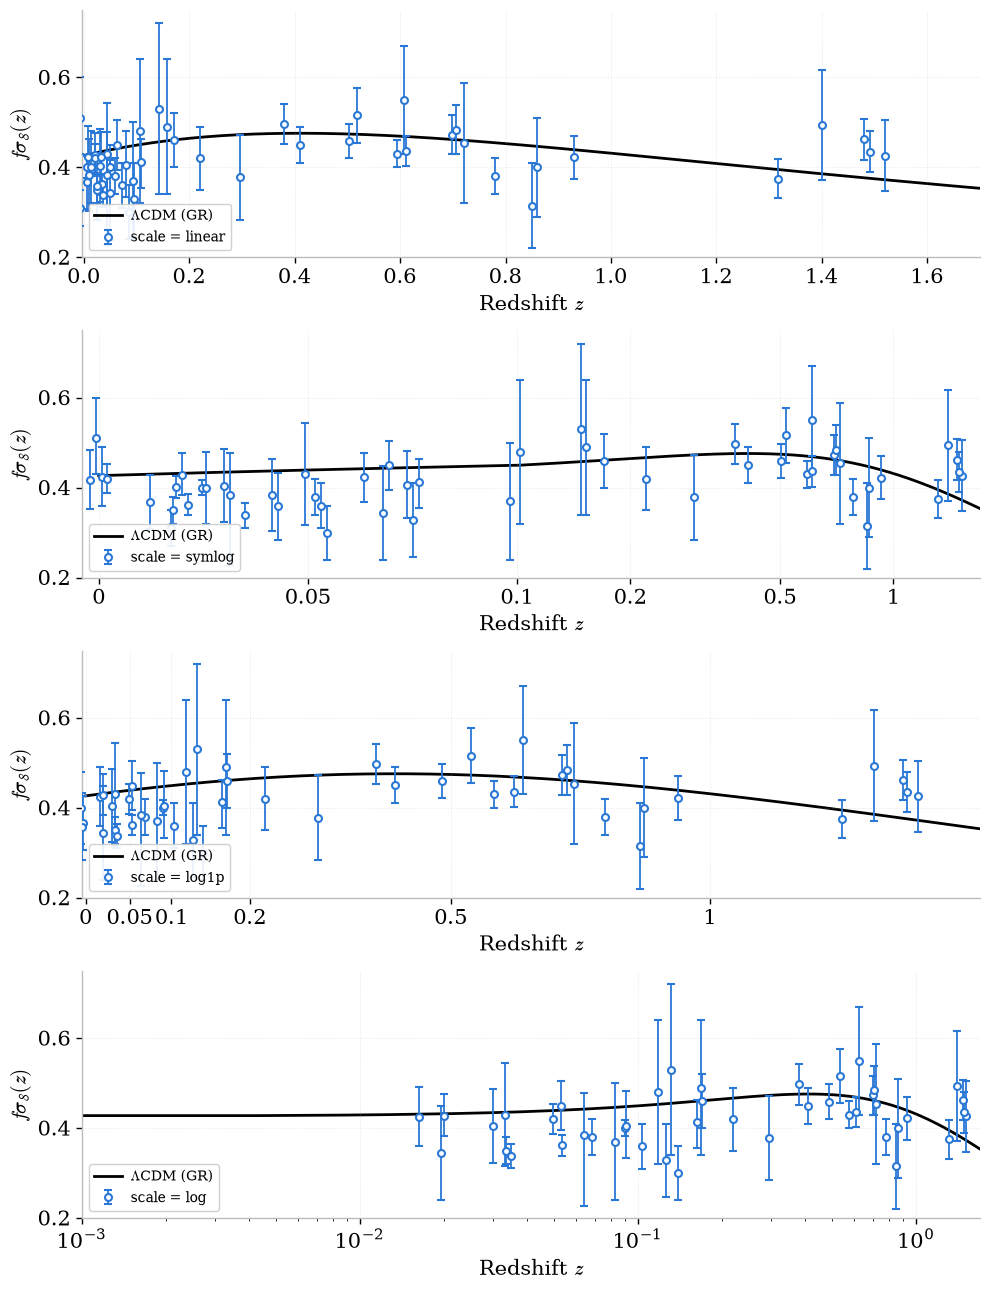

In [6]:
meas = gr.load_fsigma8(kind="measurement")

fig, axes = plt.subplots(4, 1, figsize=(10, 13))
for ax, scale in zip(axes, ["linear", "symlog", "log1p", "log"]):
    gr.plotting.plot_reference(ax, cosmo, zmax=1.7)
    x = gr.dodge_x(meas["z"].to_numpy(), min_sep=0.006, step=0.014, scale=scale)
    gr.plotting.plot_measurements(ax, meas, x=x, ms=5, color=gr.PALETTE["blue"],
                                  label=f"scale = {scale}")
    lo = 1e-3 if scale == "log" else -0.004
    gr.style_axes(ax, xlim=(lo, 1.7), ylim=(0.2, 0.75), scale=scale,
                  legend_kw=dict(loc="lower left", fontsize=10))
fig.tight_layout()

- **linear** — every peculiar-velocity point is stacked in the first 5% of the axis.
- **symlog** — linear below z = 0.1, log above. z = 0 stays on the panel and each
  regime gets roughly half the width. This is the package default for mixed panels.
- **log1p** — log(1+z) also keeps z = 0, but 1+z only runs 1 → 1.1 across the whole
  PV range, so it barely helps.
- **log** — silently drops the six z = 0 rows. Never use it on a panel with PV data.

## 5. Peculiar velocities, by method

28 points; dropped for no z_eff: ['Stahl2021', 'Stiskalek2026', 'Wang2026_group', 'Wang2026_local']


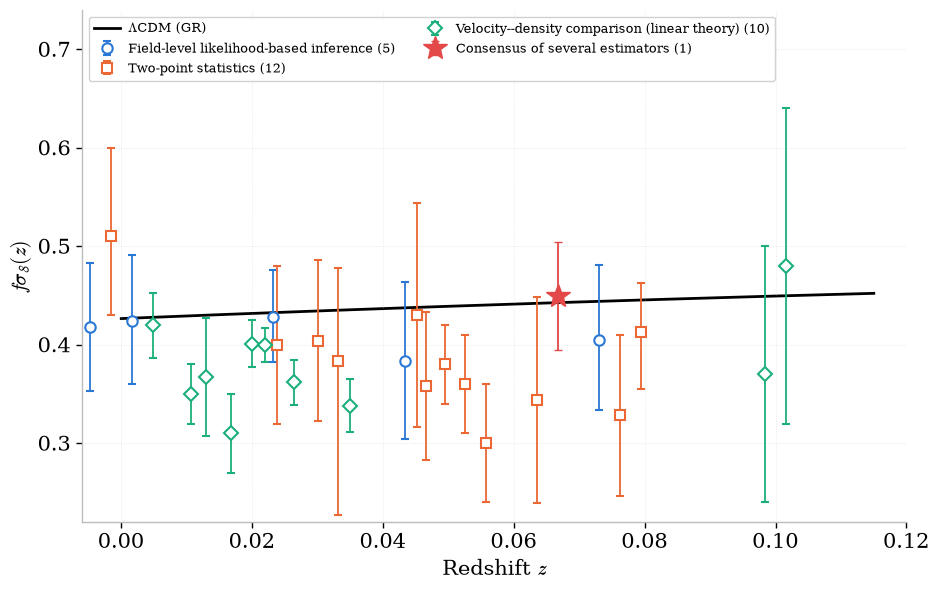

In [7]:
fig, meta = gr.figures.fig_pv()
print(f"{meta['n']} points; dropped for no z_eff: {meta['dropped_no_z']}")

Grouped by method rather than by survey deliberately. The compilation is
inhomogeneous — 6dFGSv, SDSS PV, SFI++, 2MTF and 2M++ recur across most rows and
CF3/CF4 *contain* several of them — so a per-survey legend would suggest an
independence that is not there. What does vary meaningfully is how the velocity
field is compressed before fitting.

The velocity–density family is split on the **dynamics of the prediction**:
`vd_linear` predicts the velocity field by linear theory (directly, or through a
Wiener filter / constrained realisation — still linear dynamics), while
`vd_dynamical` would evolve a particle field through a gravity solver. The second
is **empty**, and that is the result: every published fσ8 from a velocity–density
comparison is linear. The analyses that do evolve particles (Valade+2026's
particle-mesh run on CF4, Manticore-Local, Boruah–Lavaux–Hudson 2022,
Graziani+2019) publish reconstructions and evidences, not a growth rate.

Watch the word "forward model" — in Boubel 2024, Stiskalek 2026, Boruah 2020 and
Stahl 2021 it means the *distance indicator*, not the field dynamics.

Every assignment carries the sentence from its own paper that fixes it:

In [8]:
print(gr.evidence_report())


Field-level likelihood-based inference  (6)
  The likelihood of the observed density and velocity FIELD VALUES is written through a model covariance and maximised or sampled. No intermediate summary statistic is measured.
    Johnson2014              'The covariance matrix of the data'; 'P(m|d) ~ L'; the velocity field is modelled as a Gaussian random field.
    AdamsBlake2017           Lai et al. 2023: 'In the development of the maximum likelihood fields method, Adams & Blake (2017) were the first to simultaneously model...'
    Huterer2017              Section headings 'Peculiar velocity covariance' / 'Likelihood Analysis'; fits the amplitude of the signal covariance.
    AdamsBlake2020           'auto-covariance models of both probes in a fully self-consistent, maximum-likelihood method'
    DESI_DR1_maxlike         'using the maximum likelihood fields method'
    Lai2023                  'we focus on the maximum likelihood fields method to constrain the growth rate of structure'



## 6. Galaxy clustering

\caption{Measurements of $f\sigma_8(z)$ from galaxy clustering (redshift-space distortions), compared with the $\Lambda$CDM prediction for a Planck~2018 fiducial cosmology (black line). Points are coloured by survey; DESI~DR1 full-shape results are shown in red and labelled by tracer sample. Points at nearly coincident redshifts are displaced horizontally for legibility. Measurements are taken from \cite{beutler_6df_2012,howlett_clustering_2015,percival_2df_2004,blake_wigglez_2011,adame_desi_2025,collaboration_desi_2025-2,pezzotta_vimos_2017,bautista_completed_2020,gil-marin_completed_2020,tamone_completed_2020,mattia_completed_2020,okumura_subaru_2016,hou_completed_2020,neveux_completed_2020}.}


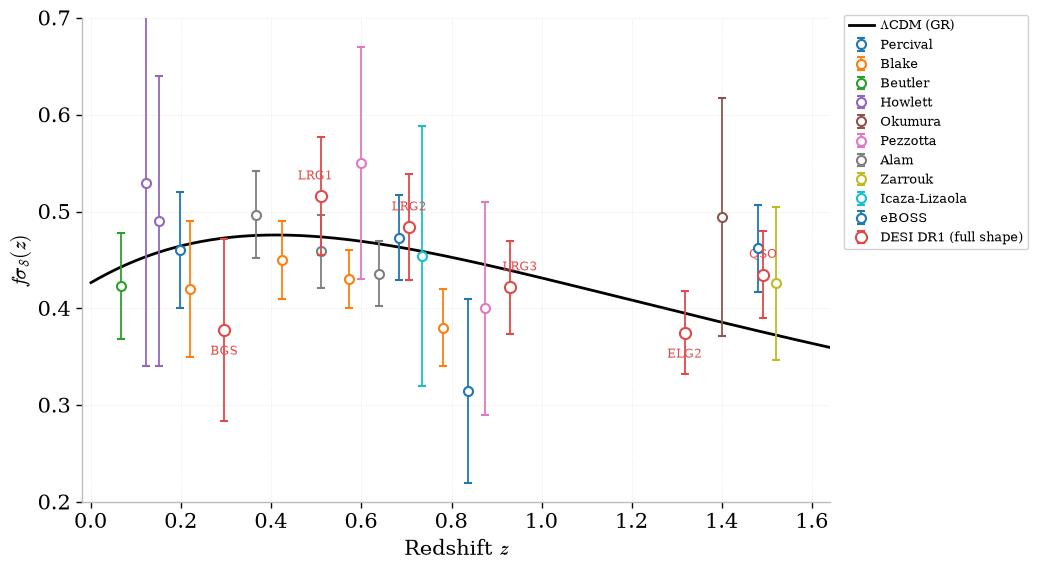

In [9]:
fig, meta = gr.figures.fig_rsd()
print(meta["caption"])

## 7. Everything at once

28 PV + 25 RSD points


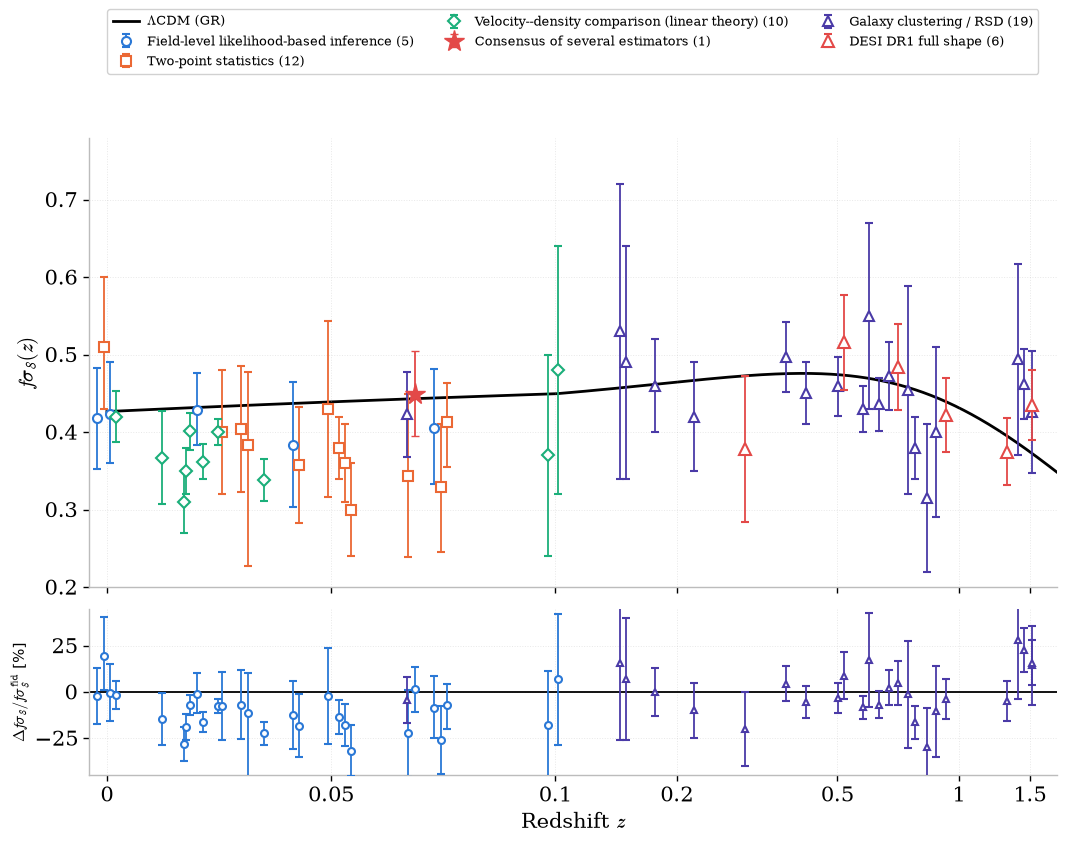

In [10]:
fig, meta = gr.figures.fig_overview()
print(f"{meta['n_pv']} PV + {meta['n_rsd']} RSD points")

## 8. Forecasts

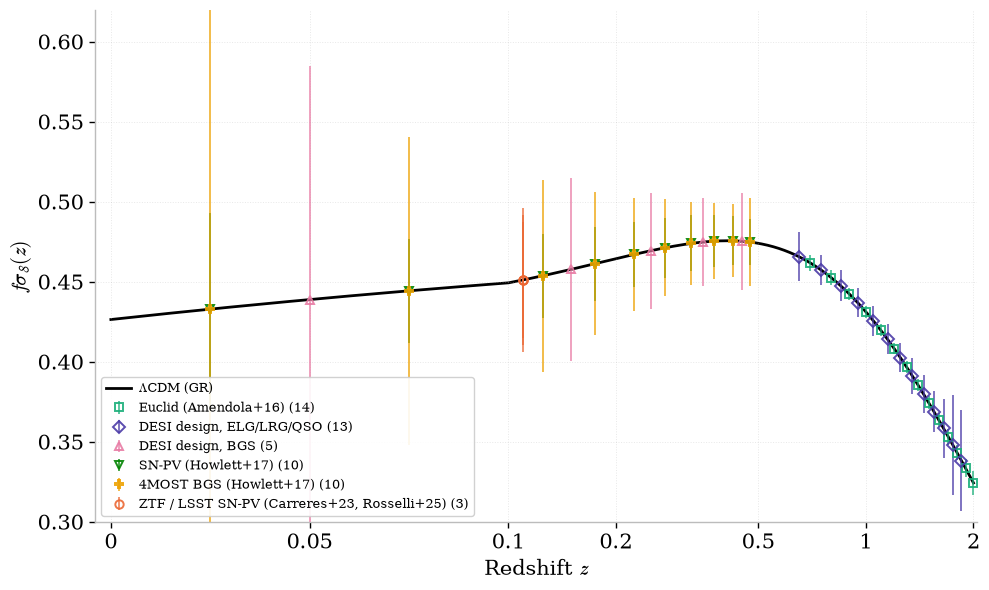

In [11]:
fig, meta = gr.figures.fig_forecasts()

## 9. Theory curves

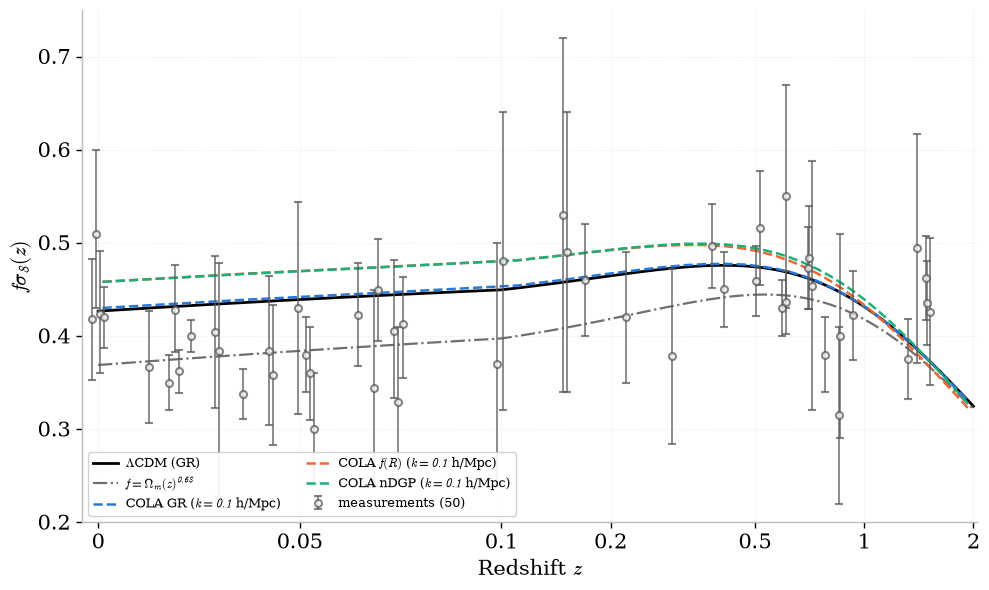

In [12]:
fig, meta = gr.figures.fig_theory(k=0.1)

The COLA GR curve lands on the package's own LCDM prediction, which is the check
that the tabulated growth is being read and normalised correctly. In f(R) the
growth rate is scale dependent, so the curve is an effective fsigma8 at one k
and not the model's growth rate — vary `k` to see how much that matters.

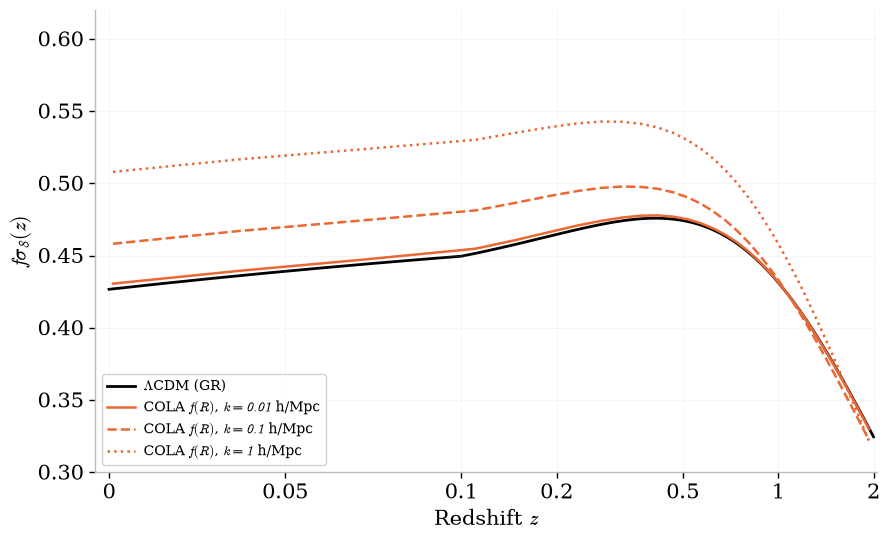

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
gr.plotting.plot_reference(ax, cosmo, zmax=2.0)
for k, ls in [(0.01, "-"), (0.1, "--"), (1.0, ":")]:
    gr.plotting.plot_theory(ax, "cola_growth_fr", sigma8=cosmo.sigma8, k=k,
                            zmax=2.0, ls=ls, color=gr.PALETTE["orange"],
                            label=rf"COLA $f(R)$, $k={k:g}$ h/Mpc")
gr.style_axes(ax, xlim=(-0.004, 2.05), ylim=(0.3, 0.62), scale="symlog",
              legend_kw=dict(loc="lower left", fontsize=10))
fig.tight_layout()

## 10. Captions, with every point cited

`cited_only=True` restricts a figure to measurements that have an entry in the
bibliography (`citations.BIBKEY`). The caption builders refuse to let a plotted
point through uncited: whatever they cannot cite comes back in
`meta["missing_citations"]`, and a figure with a non-empty list there is not
finished.

dropped, no bibliography entry: Davis2011, Feix2015, Feix2017, Franco2026, LilowNusser2021, Lyall2024, MaBranchiniScott2012, Nguyen2025, Nusser2017, Qin2019
plotted but uncitable: none

\caption{Measurements of $f\sigma_8$ from peculiar velocities at $z<0.1$, compared with the $\Lambda$CDM prediction for a Planck~2018 fiducial cosmology (black line). The compilation is inhomogeneous --- the measurements share data and differ in normalisation --- so points are grouped by the method used to extract $f\sigma_8$ rather than by survey: field-level likelihood-based inference~\cite{johnson_6df_2014,adams_improving_2017,huterer_testing_2017,adams_joint_2020,lai_using_2022}; two-point statistics~\cite{howlett_2mtf_2017,turner_local_2022,dupuy_estimation_2019,courtois_gravity_2023,qin_redshift-space_2025}; velocity--density comparison (linear theory)~\cite{boubel_large-scale_2024,carrick_cosmological_2015,hollinger_cosmological_2023,boruah_cosmic_2020,said_joint_2020}. The DESI~DR1 consensus (re

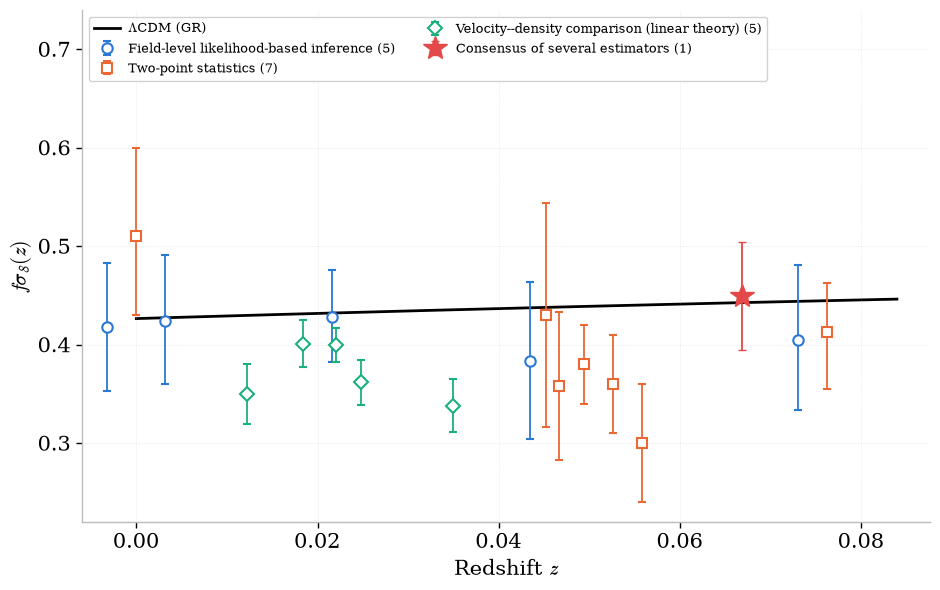

In [14]:
fig, meta = gr.figures.fig_pv(cited_only=True)
print("dropped, no bibliography entry:", ", ".join(meta["dropped"]))
print("plotted but uncitable:", meta["missing_citations"] or "none")
print()
print(meta["caption"])

dropped, no bibliography entry: Alam/BOSS_DR12, Icaza-Lizaola/DR14_LRG, Zarrouk/DR14_QSO
plotted but uncitable: none

\caption{Measurements of $f\sigma_8(z)$ from galaxy clustering (redshift-space distortions), compared with the $\Lambda$CDM prediction for a Planck~2018 fiducial cosmology (black line). Points are coloured by survey; DESI~DR1 full-shape results are shown in red and labelled by tracer sample. Points at nearly coincident redshifts are displaced horizontally for legibility. Measurements are taken from \cite{beutler_6df_2012,howlett_clustering_2015,percival_2df_2004,blake_wigglez_2011,adame_desi_2025,collaboration_desi_2025-2,pezzotta_vimos_2017,bautista_completed_2020,gil-marin_completed_2020,tamone_completed_2020,mattia_completed_2020,okumura_subaru_2016,hou_completed_2020,neveux_completed_2020}.}


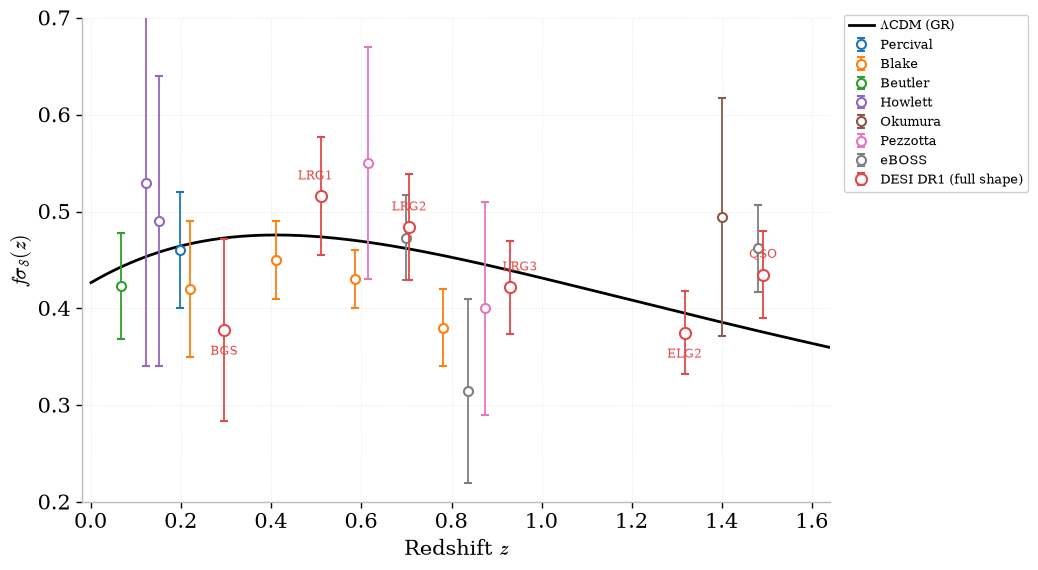

In [15]:
fig, meta = gr.figures.fig_rsd(cited_only=True)
print("dropped, no bibliography entry:", ", ".join(meta["dropped"]))
print("plotted but uncitable:", meta["missing_citations"] or "none")
print()
print(meta["caption"])

## 11. Writing every figure to disk

From the shell:

```bash
growth-review-figures --outdir figures              # full compilation
growth-review-figures --outdir figures --cited-only # only what the HDR cites
growth-review-figures --only pv rsd --format png
```

It exits non-zero if any plotted measurement could not be cited.